In [2]:
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader
from torchsummary import summary
from sklearn.model_selection import train_test_split 
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt 
import pandas as pd
import numpy as np

### GPU

In [3]:
# checking if mps is available
# import torch
# print(torch.backends.mps.is_available())

# changing to gpu
# device = torch.device("mps")

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu") 
print(device)

mps


In [4]:
# loading dataset
df = pd.read_csv("/Users/irinaaramyan/Downloads/riceClassification.csv")
df.sample(3)

,id,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
16233,16234,9023,162.315749,71.223809,0.898586,9153,107.184142,0.822441,378.988,0.789423,2.278954,0
16051,16052,9566,168.011528,73.946972,0.897934,9867,110.362174,0.784677,402.980,0.740241,2.272054,0
2836,2837,6372,152.343784,54.535100,0.933732,6584,90.072651,0.480906,346.211,0.668042,2.793500,1


### Preprocessing

In [5]:
df.isna().sum() # checking for missing vals
df.drop(columns=["id"], inplace=True)
df.head()

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
0,4537,92.229316,64.012769,0.719916,4677,76.004525,0.657536,273.085,0.764510,1.440796,1
1,2872,74.691881,51.400454,0.725553,3015,60.471018,0.713009,208.317,0.831658,1.453137,1
2,3048,76.293164,52.043491,0.731211,3132,62.296341,0.759153,210.012,0.868434,1.465950,1
3,3073,77.033628,51.928487,0.738639,3157,62.551300,0.783529,210.657,0.870203,1.483456,1
4,3693,85.124785,56.374021,0.749282,3802,68.571668,0.769375,230.332,0.874743,1.510000,1


In [6]:
df["Class"].unique() # checking how many labels we have
df["Class"].value_counts() # checking how balanced the data is

Class
1    9985
0    8200
Name: count, dtype: int64

#### Max scaling

In [7]:
original_df = df.copy() # keeping original data

for column in df.columns:
    df[column] = df[column] / df[column].abs().max()

df

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
0,0.444368,0.503404,0.775435,0.744658,0.424873,0.666610,0.741661,0.537029,0.844997,0.368316,1.0
1,0.281293,0.407681,0.622653,0.750489,0.273892,0.530370,0.804230,0.409661,0.919215,0.371471,1.0
2,0.298531,0.416421,0.630442,0.756341,0.284520,0.546380,0.856278,0.412994,0.959862,0.374747,1.0
3,0.300979,0.420463,0.629049,0.764024,0.286791,0.548616,0.883772,0.414262,0.961818,0.379222,1.0
4,0.361704,0.464626,0.682901,0.775033,0.345385,0.601418,0.867808,0.452954,0.966836,0.386007,1.0
...,...,...,...,...,...,...,...,...,...,...,...
18180,0.573262,0.811219,0.618156,0.971489,0.545785,0.757140,0.562384,0.654774,0.733291,0.744543,0.0
18181,0.742899,0.925674,0.704314,0.971683,0.709121,0.861916,0.730296,0.758107,0.708884,0.745661,0.0
18182,0.623408,0.844800,0.640916,0.972058,0.593296,0.789562,0.633098,0.673049,0.754720,0.747830,0.0
18183,0.583741,0.826356,0.623551,0.972748,0.562227,0.764030,0.555396,0.675248,0.702103,0.751874,0.0


#### Splitting data

In [8]:
y = np.array(df)[:, -1]
x = np.array(df)[:, :-1]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=0)
x_test, x_val, y_test, y_val = train_test_split(x_test, y_test, test_size=0.5, random_state=0) # validation set

#### Dataset class to convert the data into tensors and work with them

In [9]:
class dataset(Dataset):
    def __init__(self, x, y):
        self.x = torch.tensor(x, dtype=torch.float32) # converts the data into tensors
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self): # tells how many samples exist
        return len(self.x)
    
    def __getitem__(self, index): # how to fetch one sample
        return self.x[index], self.y[index]

In [10]:
training_data = dataset(x_train, y_train)
testing_data = dataset(x_test, y_test)
val_data = dataset(x_val, y_val)

training_data

#### Data Loader

In [11]:
bs = 16
train_dataloader = DataLoader(training_data, batch_size=bs, shuffle=True)
test_dataloader = DataLoader(testing_data, batch_size=bs, shuffle=True)
val_dataloader = DataLoader(val_data, batch_size=bs, shuffle=True)

for x, y in train_dataloader:
    print(x)
    print(y)
    break

tensor([[0.8470, 0.8567, 0.8588, 0.9228, 0.8075, 0.9203, 0.8337, 0.7354, 0.8588,
         0.5660],
        [0.6911, 0.6962, 0.8761, 0.8520, 0.6566, 0.8313, 0.8469, 0.6503, 0.8961,
         0.4508],
        [0.6472, 0.8527, 0.6650, 0.9684, 0.6181, 0.8045, 0.6999, 0.6930, 0.7392,
         0.7275],
        [0.8307, 0.8630, 0.8394, 0.9297, 0.7874, 0.9114, 0.6623, 0.7363, 0.8403,
         0.5833],
        [0.6090, 0.8837, 0.6044, 0.9840, 0.5903, 0.7804, 0.8375, 0.7016, 0.6785,
         0.8296],
        [0.7046, 0.9392, 0.6546, 0.9820, 0.6680, 0.8394, 0.6380, 0.7392, 0.7072,
         0.8140],
        [0.6792, 0.9109, 0.6580, 0.9780, 0.6458, 0.8242, 0.5087, 0.7265, 0.7057,
         0.7854],
        [0.7086, 0.7806, 0.8068, 0.9154, 0.6840, 0.8418, 0.6400, 0.6875, 0.8222,
         0.5489],
        [0.7171, 0.9137, 0.6884, 0.9730, 0.6806, 0.8468, 0.5818, 0.7244, 0.7494,
         0.7531],
        [0.6186, 0.8763, 0.6170, 0.9809, 0.5951, 0.7865, 0.7421, 0.7051, 0.6824,
         0.8058],
        [0

### Fitting

In [12]:
hidden_neurons = 10
class MyModel(nn.Module):
    def __init__(self):
        super(MyModel, self).__init__()
        # x.shape => n_features
        self.input_layer = nn.Linear(x.shape[1], hidden_neurons)
        self.relu = nn.ReLU()
        self.hidden_layer = nn.Linear(hidden_neurons, 1)
        self.sigmoid = nn.Sigmoid()


    def forward(self, x):
        x = self.input_layer(x) # x is input layer
        x = self.relu(x) # after relu activation function
        x = self.hidden_layer(x) # result of input layer goes to hidden layer
        x = self.sigmoid(x) # activation function applied (output)
        return x
    

In [13]:
model = MyModel()

summary(model, (x.shape[1],)) # makes a tuple

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                   [-1, 10]             110
              ReLU-2                   [-1, 10]               0
            Linear-3                    [-1, 1]              11
           Sigmoid-4                    [-1, 1]               0
Total params: 121
Trainable params: 121
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00
----------------------------------------------------------------


In [14]:
criterion = nn.BCELoss() # cross entropy loss 
optimizer = Adam(model.parameters(), lr=0.01)

### Training function

In [15]:
total_loss_train_saver = []
total_loss_val_saver = []
total_accuracy_train_saver = []
total_accuracy_val_saver = []

epochs = 100
for epoch in range(epochs):
    total_loss_train = 0
    total_loss_val = 0
    total_accuracy_train = 0
    total_accuracy_val = 0

    for data in train_dataloader:
        inputs, labels = data 
        
        pred = model(inputs).flatten()

        batch_loss = criterion(pred, labels) # loss
        total_loss_train += batch_loss.item() / len(train_dataloader) # only the number

        acc = (pred.round() == labels).sum().item()
        total_accuracy_train += acc / len(training_data)

        batch_loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        
    with torch.no_grad():
        for data in val_dataloader:
            inputs, labels = data 

            pred = model(inputs).flatten()

            batch_loss = criterion(pred, labels)
            total_loss_val += batch_loss.item() / len(val_dataloader)

            acc = (pred.round() == labels).sum().item()
            total_accuracy_val += acc / len(val_data)

    total_loss_train_saver.append(total_loss_train)
    total_loss_val_saver.append(total_loss_val)
    total_accuracy_train_saver.append(total_accuracy_train)
    total_accuracy_val_saver.append(total_accuracy_val)
    print(f"""Epoch: {epoch}, training loss: {total_loss_train},
          training accuracy: {total_accuracy_train*100}%,
          validation loss: {total_loss_val}, validation accuracy: {total_accuracy_val*100}%

""")

Epoch: 0, training loss: 0.17456108169342327,
          training accuracy: 96.03268127896914%,
          validation loss: 0.05688847076115118, validation accuracy: 98.46041055718467%


Epoch: 1, training loss: 0.04651327322428198,
          training accuracy: 98.62518658182083%,
          validation loss: 0.05177989227279248, validation accuracy: 98.27712609970666%


Epoch: 2, training loss: 0.04393451535874941,
          training accuracy: 98.52305758504183%,
          validation loss: 0.05179917835766637, validation accuracy: 98.60703812316707%


Epoch: 3, training loss: 0.04157845928384451,
          training accuracy: 98.65661088852202%,
          validation loss: 0.04920516077756515, validation accuracy: 98.64369501466268%


Epoch: 4, training loss: 0.04191236009223276,
          training accuracy: 98.578050121769%,
          validation loss: 0.06777670100274802, validation accuracy: 98.02052785923746%


Epoch: 5, training loss: 0.041276844310821806,
          training accuracy: 9

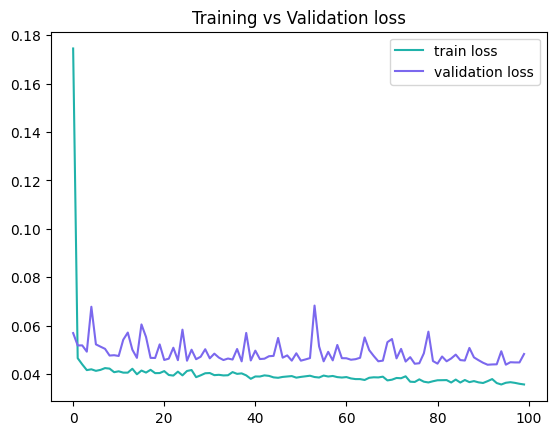

In [16]:
plt.plot(total_loss_train_saver, label="train loss", color="LightSeaGreen")
plt.plot(total_loss_val_saver, label="validation loss", color="MediumSlateBlue")
plt.title("Training vs Validation loss")
plt.legend()
plt.show()

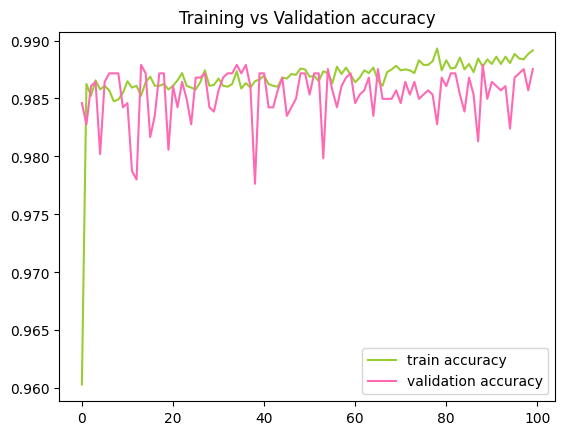

In [17]:
plt.plot(total_accuracy_train_saver, label="train accuracy", color="YellowGreen")
plt.plot(total_accuracy_val_saver, label="validation accuracy", color="hotpink")
plt.title("Training vs Validation accuracy")
plt.legend()
plt.show()